# Multi-participant regime-switching SSMs with `RSSSM`

This tutorial scales `hssm.RSSSM` to a **multi-participant panel with `K = 3` regimes**. It exercises the batched forward recursion over participants, the `ordered`-transform anchor at `K = 3`, and post-hoc regime recovery with `infer_regimes`.

See the *"Regime-Switching SSMs with RSSSM: a first example"* tutorial for the single-participant introduction. Here we simulate four participants who each switch between three drift-rate regimes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hssm

%config InlineBackend.figure_format = 'retina'

## 1. Simulate a panel

Three regimes with well-separated drift rates `v = [-1.0, 0.5, 1.8]`; `a`, `z`, `t` shared. Each of the four participants has 200 trials drawn from the same sticky 3-state Markov chain. Panels may be unbalanced, but here we keep them equal for simplicity.

In [2]:
def simulate_participant(n_trials, v_per_regime, a, z, t, P, pi0, seed):
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])
    data = np.empty((n_trials, 2))
    for k in range(K):
        m = regimes == k
        n_k = int(m.sum())
        if n_k:
            data[m] = hssm.simulate_data(
                model="ddm", theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
    return data, regimes


V_TRUE = [-1.0, 0.5, 1.8]
P = np.array([[0.9, 0.05, 0.05], [0.05, 0.9, 0.05], [0.05, 0.05, 0.9]])
pi0 = np.ones(3) / 3

frames, true_regimes = [], {}
for pid in range(4):
    data, regimes = simulate_participant(200, V_TRUE, a=1.0, z=0.5, t=0.3, P=P, pi0=pi0, seed=10 + pid)
    sub = pd.DataFrame(data, columns=["rt", "response"])
    sub["participant_id"] = pid
    frames.append(sub)
    true_regimes[pid] = regimes
df = pd.concat(frames, ignore_index=True)
df.groupby("participant_id").size()

participant_id
0    200
1    200
2    200
3    200
dtype: int64

## 2. Build and fit

`participant_col` identifies the panel structure. Under the default *full pooling* the regime parameters are global (shared across participants); the transition matrix `P` and initial distribution `pi0` are always global. The drift rate switches across the three regimes and anchors the ordering.

In [3]:
model = hssm.RSSSM(
    data=df,
    model="ddm",
    K=3,
    switching_params=["v"],
    participant_col="participant_id",
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)

RSSSM model initialized successfully.


In [4]:
idata = model.sample(draws=500, tune=500, chains=2, target_accept=0.9, random_seed=42)
model.summary()

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   0%|          | 1/1000 [00:00<15:32,  1.07it/s, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   1%|          | 7/1000 [00:01<01:52,  8.84it/s, 63 steps of size 7.16e-03. acc. prob=0.57]

warmup:   1%|          | 11/1000 [00:01<01:36, 10.26it/s, 63 steps of size 9.30e-03. acc. prob=0.70]

...

sample:  99%|█████████▉| 994/1000 [00:23<00:00, 51.25it/s, 31 steps of size 2.24e-01. acc. prob=0.94]

sample: 100%|██████████| 1000/1000 [00:23<00:00, 52.09it/s, 31 steps of size 2.24e-01. acc. prob=0.94]

sample: 100%|██████████| 1000/1000 [00:23<00:00, 42.86it/s, 31 steps of size 2.24e-01. acc. prob=0.94]

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,500,3,2]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z,0.497,0.012,0.472,0.519,0.000,0.000,1247.0,749.0,1.00
t,0.305,0.009,0.288,0.319,0.000,0.000,1117.0,883.0,1.00
v[0],-1.044,0.115,-1.268,-0.838,0.004,0.004,670.0,685.0,1.00
v[1],0.387,0.096,0.211,0.563,0.003,0.003,933.0,857.0,1.00
v[2],1.762,0.118,1.547,1.988,0.003,0.003,1255.0,704.0,1.00
"P[0, 0]",0.891,0.025,0.845,0.937,0.001,0.001,951.0,858.0,1.00
"P[0, 1]",0.032,0.019,0.002,0.066,0.001,0.001,603.0,463.0,1.00
"P[0, 2]",0.077,0.022,0.036,0.117,0.001,0.001,1059.0,729.0,1.00
"P[1, 0]",0.043,0.021,0.010,0.082,0.001,0.001,697.0,661.0,1.01
"P[1, 1]",0.927,0.025,0.874,0.965,0.001,0.001,707.0,644.0,1.00


The three drift rates are recovered ordered and close to the true `[-1.0, 0.5, 1.8]`, with no label-switching across chains (the `ordered` transform makes the permuted modes unreachable).

## 3. Recover the regimes for each participant

`infer_regimes` returns a `posterior_regimes` group with per-draw regime sequences and the Monte-Carlo `regime_sample_frequency` for every `(participant, trial)`. We plot the recovered regime probabilities against the ground truth for each participant.

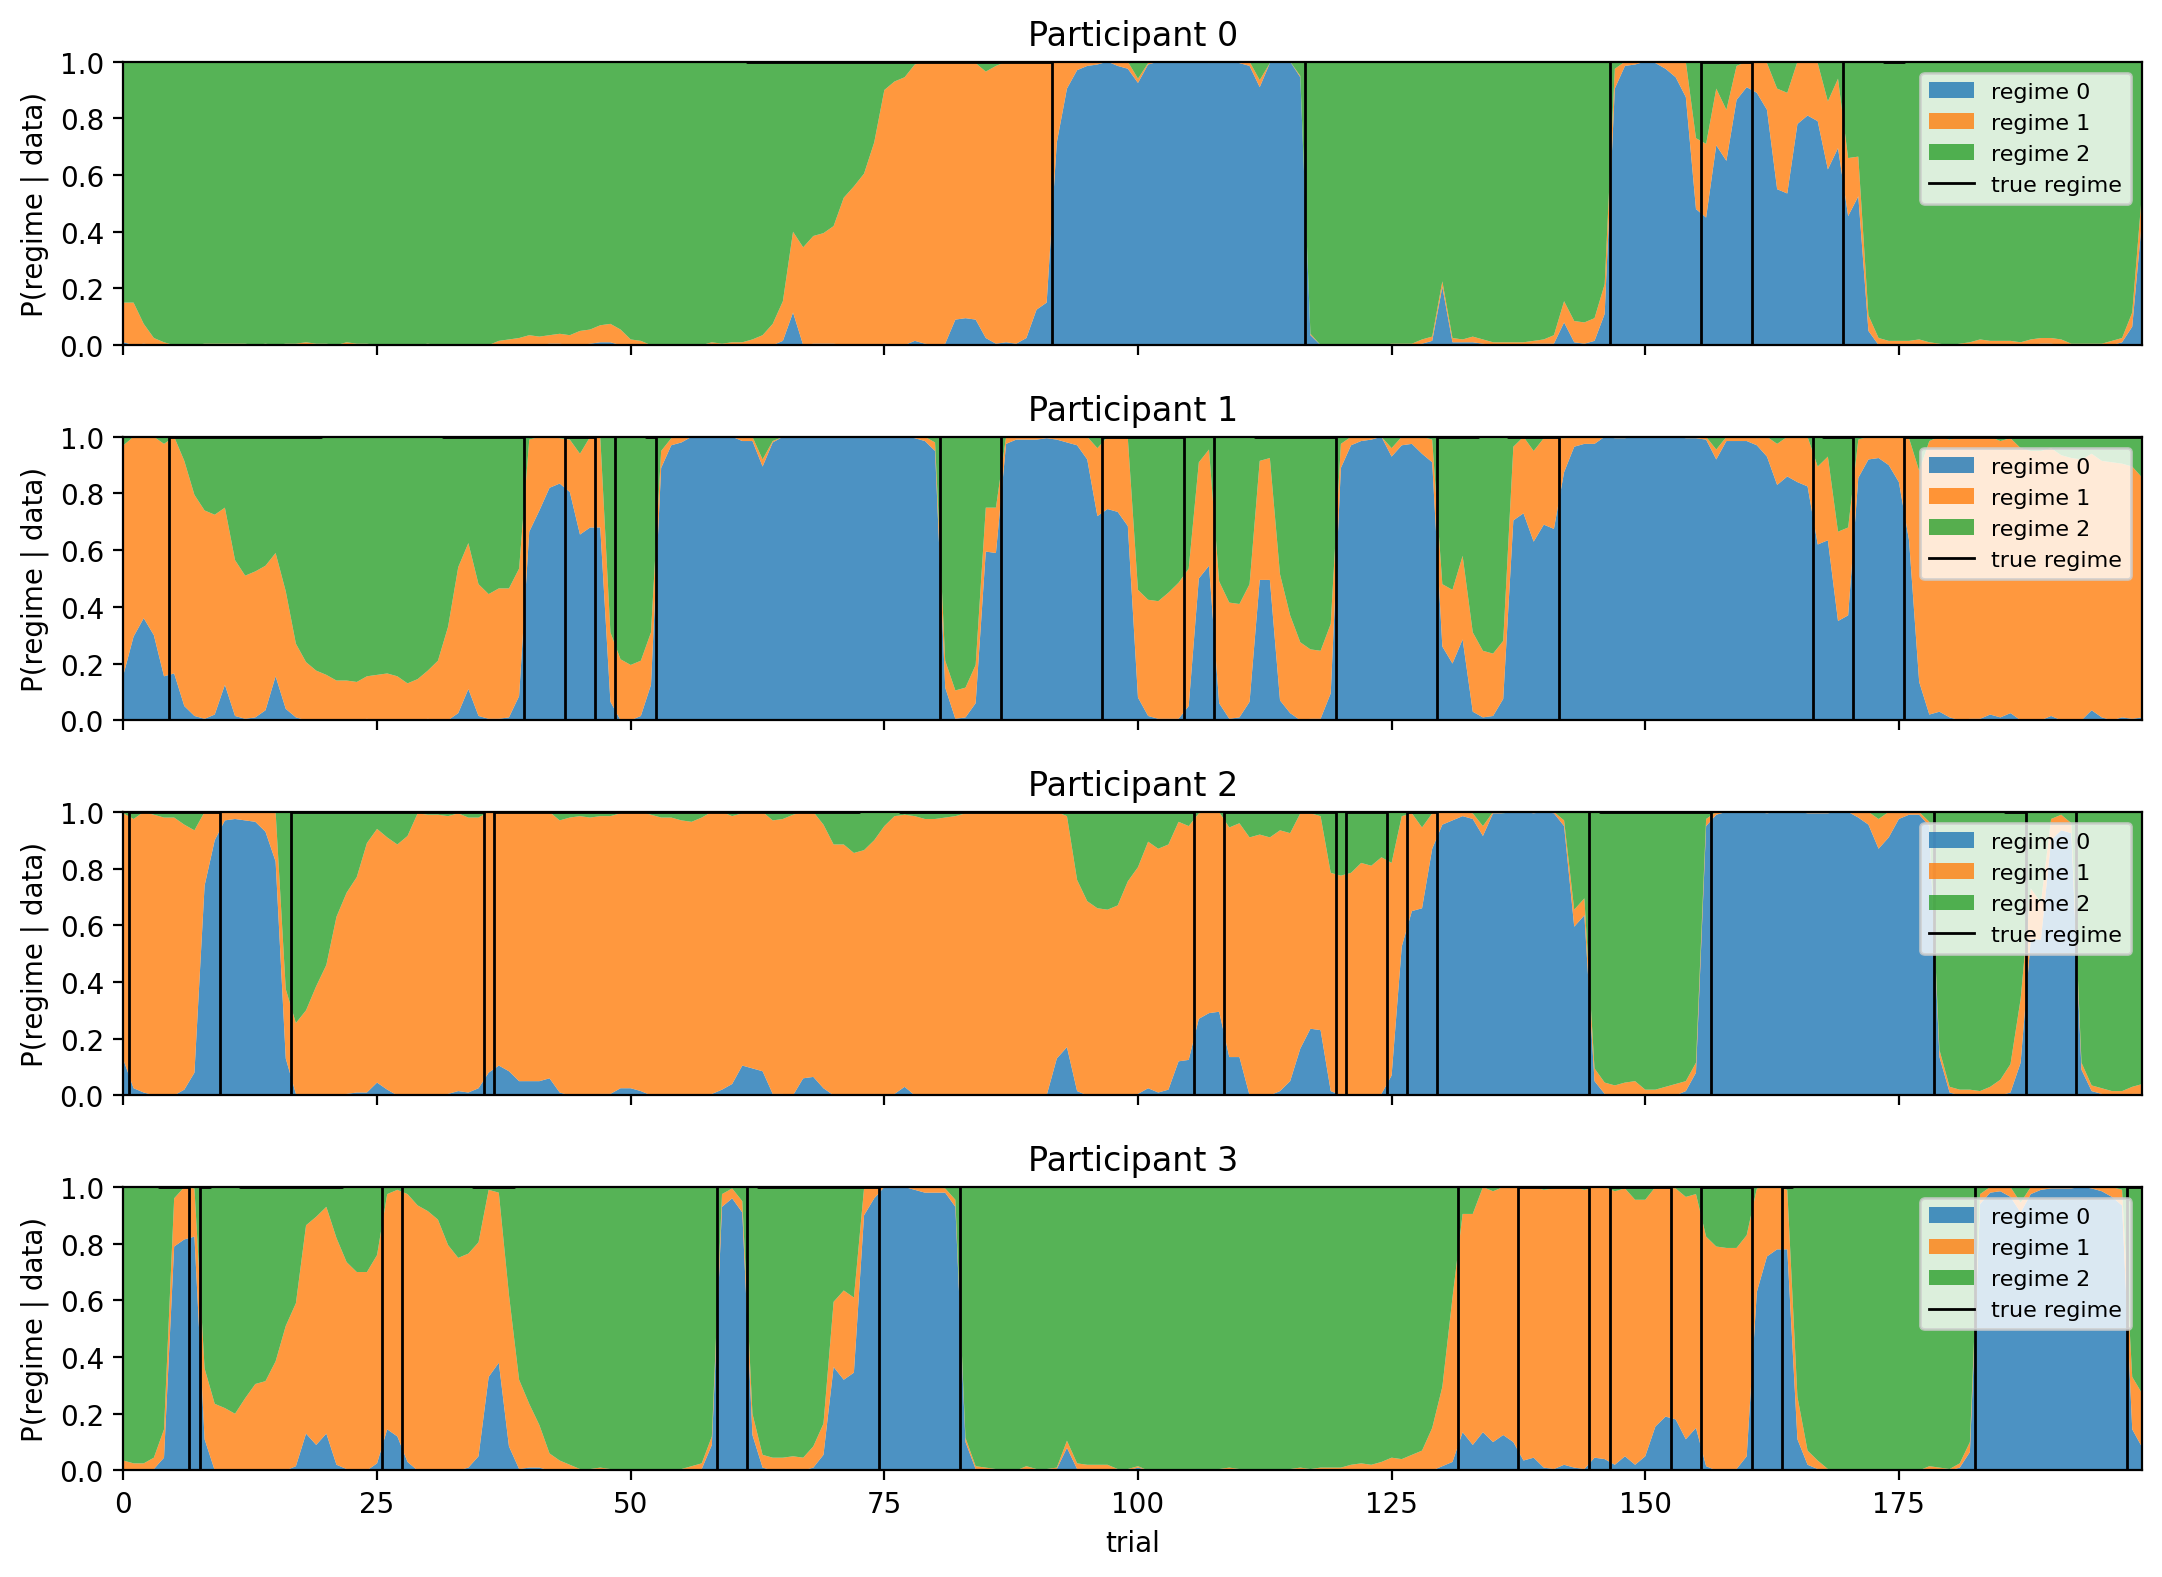

In [5]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
for pid, ax in enumerate(axes):
    model.plot_regime_recovery(regimes_idata, participant=pid, true_regimes=true_regimes[pid], ax=ax)
    ax.set_title(f"Participant {pid}")
    if pid < 3:
        ax.set_xlabel("")
fig.tight_layout()